# Imports

In [116]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from scipy.integrate import cumulative_trapezoid
from scipy import constants
from urllib.request  import urlopen #python 3.0 
from urllib.request  import urlretrieve #python 3.0 
import urllib
import os
from enum import Enum

# The following line activates the inline plotting backend in the notebook.
%matplotlib inline

### Utility functions

In [117]:
def print_warning(message):
    print('\033[91m' + message + '\033[0m')

# Setup

### Constants

In [118]:
V_p = 0.057 #m^3 Plasma volume
k_B = constants.k # Boltzmann constant
eV = constants.e # 1 eV equivalent to J

ShotNo = 48251
VacuumShotNo = ShotNo

In [119]:
class Parameter(Enum):
    U_loop = ('Diagnostics/BasicDiagnostics/Results/U_loop', 1)
    I_p = ('Diagnostics/BasicDiagnostics/Results/Ip', 1e3)
    I_ch = ('Diagnostics/BasicDiagnostics/Results/Ich', 1e3)
    n_e_lav = ('Diagnostics/Interferometry/Results/ne_lav')

    def __init__(self, path, conversion_factor=1):
        self.path = path
        self.conversion_factor = conversion_factor

### Data acquisition functions

In [120]:
baseURL = "http://golem.fjfi.cvut.cz/shots/"

try:
        os.stat('shots/')
except:
        os.mkdir('shots/') 

def open_data(shot_no, paremeter:Parameter):
    data_path = paremeter.path
    shotDIR = 'shots/' + str(shot_no)
    dataADR = shotDIR + '/' + str(paremeter.name) + '.csv' # where we put it
    dataURL = baseURL + str(shot_no) + '/' + data_path + '.csv' # where we get it
    
    try:
        os.stat(shotDIR)
        # print('Directory ' + shotDIR + ' already exists.')
    except:
        os.mkdir(shotDIR) 

    try:
        data = np.genfromtxt(dataADR, delimiter=',', skip_header=1)
    except:    
        download_data(dataURL, dataADR)
        data = np.genfromtxt(dataADR, delimiter=',', skip_header=1)

    return data 

def download_data(URL, download_to_path):
        print('Downloading data from ' + URL + ' into ' + download_to_path)
        a = urlretrieve(URL, download_to_path)
        print(a)

In [121]:
def GetParameterDataFromShot(shot_no, parameter:Parameter):
    data = open_data(shot_no, parameter)
    return data[:,0], data[:,1]*parameter.conversion_factor # time, data

In [122]:
def InterpolateDataToTimeArray(time, data, new_time):
    return np.interp(new_time, time, data)

# Data acquisition

In [123]:
times = {}
datas = {}

for i, paremeter in enumerate(Parameter):
    time, data = GetParameterDataFromShot(ShotNo, paremeter)
    times[paremeter] = time
    datas[paremeter] = data


('shots/48251/U_loop.csv', <http.client.HTTPMessage object at 0x0000020FA3206AE0>)
('shots/48251/I_p.csv', <http.client.HTTPMessage object at 0x0000020FA3FC03B0>)
('shots/48251/I_ch.csv', <http.client.HTTPMessage object at 0x0000020FA39C7F50>)
('shots/48251/n_e_lav.csv', <http.client.HTTPMessage object at 0x0000020FA3F8D2B0>)


### Handle time array

In [124]:
# Test that time arrays are sorted
for paremeter, time in times.items():
    if not np.all(np.diff(time) > 0):
        # Warning in red
        print_warning('Time array for ' + str(paremeter) + ' is not sorted!')

In [125]:
# Make sure everything has the same time scale

# First find minimum and maxmium time across all data
min_time = min([time[0] for time in times.values()])
max_time = max([time[-1] for time in times.values()])

time_baseline = Parameter.U_loop

for i, parameterID in enumerate(Parameter):
    # discard data outside of the common time range
    if times[parameterID][0] < min_time or times[parameterID][-1] > max_time:
        common_time_range_mask = (times[parameterID] >= min_time) & (times[parameterID] <= max_time)
        times[parameterID] = times[parameterID][common_time_range_mask]
        datas[parameterID] = datas[parameterID][common_time_range_mask]

    # interpolate to the time baseline if not already on it
    if times[parameterID] is not times[time_baseline]:
        datas[parameterID] = InterpolateDataToTimeArray(times[parameterID], datas[parameterID], times[time_baseline])
        times[parameterID] = times[time_baseline]


# Check that all time arrays are now the same
for paremeter, time in times.items():
    if not np.array_equal(time, times[time_baseline]):
        print_warning('Time array for ' + str(paremeter) + ' is not the same as the baseline time array!')

time = times[time_baseline]

### Put data into named variables

In [126]:
U_loop = datas[Parameter.U_loop]
I_p = datas[Parameter.I_p]

### Plot obtained data

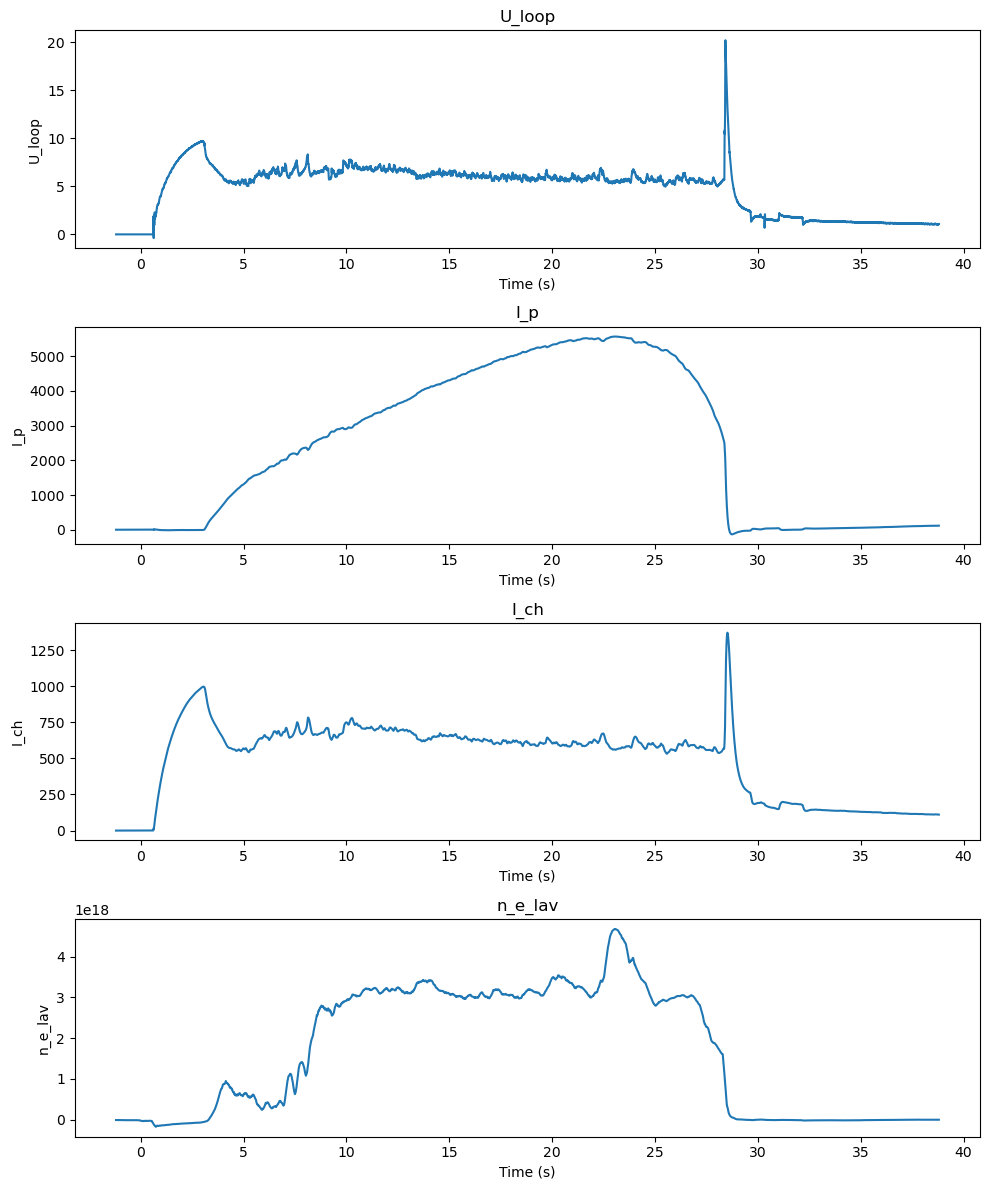

In [127]:
fig, axs = plt.subplots(len(Parameter), 1, figsize=(10, 3*len(Parameter)))
for i, paremeter in enumerate(Parameter):
    time, data = times[paremeter], datas[paremeter]
    axs[i].plot(time, data)
    axs[i].set_title(str(paremeter.name))
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel(str(paremeter.name))
plt.tight_layout()
plt.show()

# Data Processing